In [25]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

In [26]:
os.environ["PATH"] = "/vast/palmer/apps/avx2/software/texlive/20220321-GCC-12.2.0/bin/x86_64-linux:" + os.environ["PATH"]
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{lmodern}",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "figure.figsize": [7, 4.9],
    "svg.fonttype": "none",
    "image.cmap": "viridis",
})

In [27]:
os.environ["JAX_PLATFORMS"] = "cpu"

import jax
jax.config.update("jax_enable_x64", True)

from jaxdem.utils.h5 import load
from jaxdem.utils.packing_utils import compute_packing_fraction

In [32]:
UNIFORM_JAM_DIR = Path("/home/rg2248/palmer_scratch/data/summer-26/jam-uniform/n-1000")
UNIFORM_SAMPLE_DIR = Path("/home/rg2248/project/friction/data/local-friction/uniform/sample")

# Must match friction/uniform/sample/sample_friction.py
N_ORIENTATIONS = 5009
N_POINTS = 5003

CONTACT_TYPES = {
    "ss": ("Small--small", "s", "blue"),
    "sl": ("Small--large", "^", "red"),
    "ll": ("Large--large", "D", "black"),
}

In [29]:
def load_mu_values(jam_dir, sample_dir):
    jam_mu = set()
    for run_dir in jam_dir.iterdir():
        if not run_dir.is_dir() or not run_dir.name.isdigit():
            continue
        for mu_dir in run_dir.iterdir():
            if mu_dir.is_dir() and mu_dir.name.startswith("mu-"):
                jam_mu.add(float(mu_dir.name.removeprefix("mu-")))

    sample_mu = {
        float(path.stem.removeprefix("mu-"))
        for path in sample_dir.glob("mu-*.npz")
    }
    return np.array(sorted(jam_mu & sample_mu))


def jammed_packing_fractions(data_root, mu_eff):
    packing_fractions = []

    for run_dir in sorted(data_root.iterdir(), key=lambda path: int(path.name)):
        if not run_dir.is_dir() or not run_dir.name.isdigit():
            continue

        run_path = run_dir / f"mu-{mu_eff}"
        state_path = run_path / "state.h5"
        system_path = run_path / "system.h5"
        if not state_path.exists() or not system_path.exists():
            continue

        state = load(state_path)
        system = load(
            system_path,
            state_shape=state.shape,
            warn_missing=False,
        )
        packing_fractions.append(float(compute_packing_fraction(state, system)))

    if not packing_fractions:
        raise FileNotFoundError(f"No jammed runs found for mu_eff={mu_eff} in {data_root}")

    return np.asarray(packing_fractions)


def sampled_friction_stats(sample_dir, mu_eff, contact_key):
    values = np.asarray(np.load(sample_dir / f"mu-{mu_eff}.npz")[contact_key])
    values = values.reshape(N_ORIENTATIONS, N_POINTS)

    orientation_means = values.mean(axis=1)
    mean = float(values.mean())
    sem = float(orientation_means.std(ddof=1) / np.sqrt(N_ORIENTATIONS))

    return mean, sem


def mean_sem(values):
    values = np.asarray(values)
    mean = float(values.mean())
    sem = float(values.std(ddof=1) / np.sqrt(values.size)) if values.size > 1 else 0.0
    return mean, sem

In [30]:
mu_eff = load_mu_values(UNIFORM_JAM_DIR, UNIFORM_SAMPLE_DIR)

phi_j_mean = np.zeros(mu_eff.size)
phi_j_sem = np.zeros(mu_eff.size)
sampled_mean = {key: np.zeros(mu_eff.size) for key in CONTACT_TYPES}
sampled_sem = {key: np.zeros(mu_eff.size) for key in CONTACT_TYPES}

for i, mu in enumerate(mu_eff):
    phi_j_mean[i], phi_j_sem[i] = mean_sem(
        jammed_packing_fractions(UNIFORM_JAM_DIR, mu)
    )

    for key in CONTACT_TYPES:
        mean, sem = sampled_friction_stats(UNIFORM_SAMPLE_DIR, mu, key)
        sampled_mean[key][i] = mean
        sampled_sem[key][i] = sem

/tmp/ipykernel_2857443/1458291328.py:10: RuntimeWarning: h5: State: unknown saved fields ['unique_id'] - skipping
  jammed_packing_fractions(UNIFORM_JAM_DIR, mu)


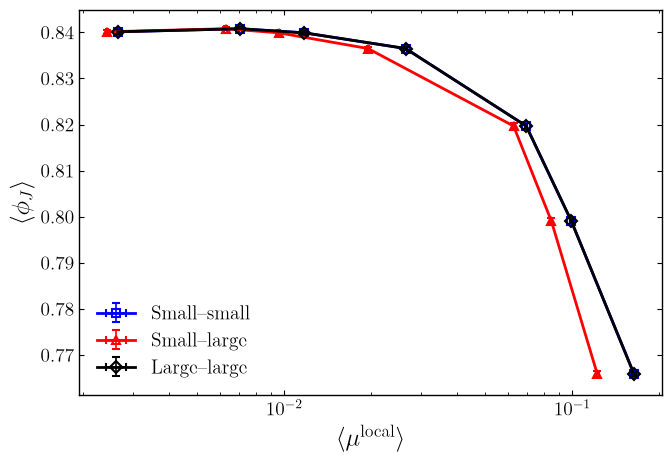

In [37]:
fig, ax = plt.subplots()

for key, (label, marker, color) in CONTACT_TYPES.items():
    order = np.argsort(sampled_mean[key])
    x = sampled_mean[key][order]
    xerr = sampled_sem[key][order]
    y = phi_j_mean[order]
    yerr = phi_j_sem[order]

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        color=color,
        marker=marker,
        markerfacecolor="none",
        markeredgewidth=1.5,
        markeredgecolor=color,
        linestyle="-",
        capsize=3,
        elinewidth=1.2,
        label=label,
    )

ax.set_xlabel(r"$\langle\mu^{\mathrm{local}}\rangle$")
ax.set_ylabel(r"$\langle\phi_J\rangle$")
ax.set_xscale("log")
ax.legend(frameon=False)
plt.tight_layout()

figure_path = Path("../figures/jam/phi_j.png")
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=600, bbox_inches="tight")
plt.show()